<a href="https://colab.research.google.com/github/VitorBZS/Avaliacao-02-AAPL-Apple-Volatilidade/blob/main/prova_02_vitor_bonilha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Extração

##Configurações

In [182]:
import pandas as pd
import requests
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [183]:
API_KEY = "0XRTPWUZLEA2ZAG0"
SYMBOL = "AAPL"
url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={SYMBOL}&outputsize=compact&apikey={API_KEY}"

##Extração e Conversão Inicial

In [184]:
response = requests.get(url)
data = response.json()

df = pd.DataFrame.from_dict(data["Time Series (Daily)"], orient = "index")
df.columns = ["open", "high", "low", "close", "volume"]
df = df.astype(float)
df.index = pd.to_datetime(df.index)
df.sort_index(ascending = True, inplace = True)

df.head()

,open,high,low,close,volume
2025-12-10,277.750,279.75,276.44,278.78,33038318.0
2025-12-11,279.095,279.59,273.81,278.03,33247986.0
2025-12-12,277.900,279.22,276.82,278.28,39532887.0
2025-12-15,280.150,280.15,272.84,274.11,50409078.0
2025-12-16,272.820,275.50,271.79,274.61,37648628.0


#2. Tratamento e Normalização

## Verificação de Nulos

In [185]:
print(df.isnull().sum())

open      0
high      0
low       0
close     0
volume    0
dtype: int64


## Engenharia de Preditores (X)

In [186]:
df['amplitude_raw'] = df['high'] - df['low']
df['X_amplitude'] = df['amplitude_raw'].shift(1)
df['X_volume'] = df['volume'].shift(1)
df_clean = df.dropna().copy()

## Aplicação do StandardScaler

In [187]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[['X_amplitude', 'X_volume']])

## DataFrame de Preditores (X)

In [188]:
X = pd.DataFrame(X_scaled, columns = ['amplitude_norm', 'volume_norm'], index = df_clean.index)

#3. Visualização

## Gráfico de Fechamento

Text(0.5, 1.0, 'Fechamento AAPL')

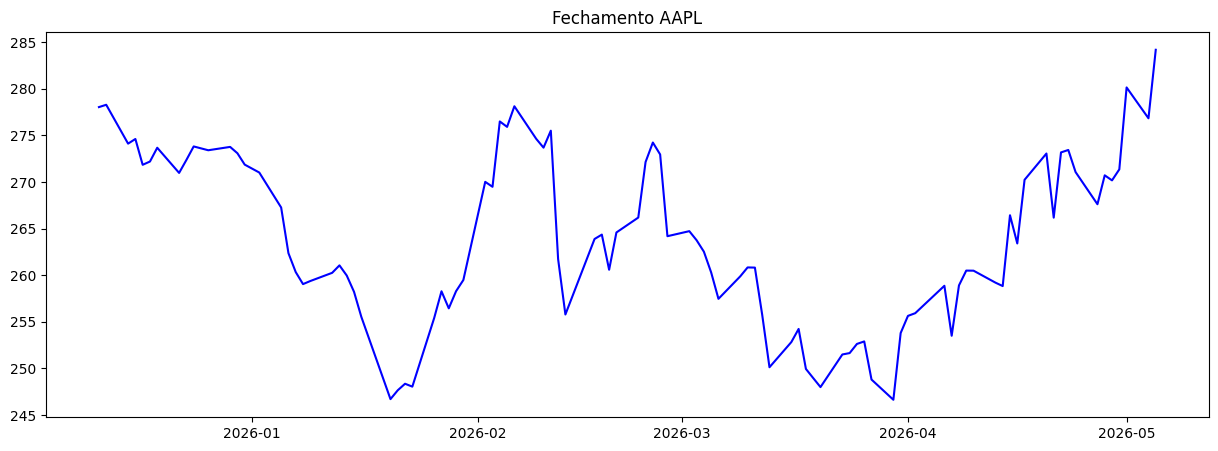

In [203]:
plt.figure(figsize = (15, 5))

plt.plot(df_clean['close'], color= 'blue')
plt.title('Fechamento AAPL')

## Gráfico de Volume

Text(0.5, 1.0, 'Volume Diário')

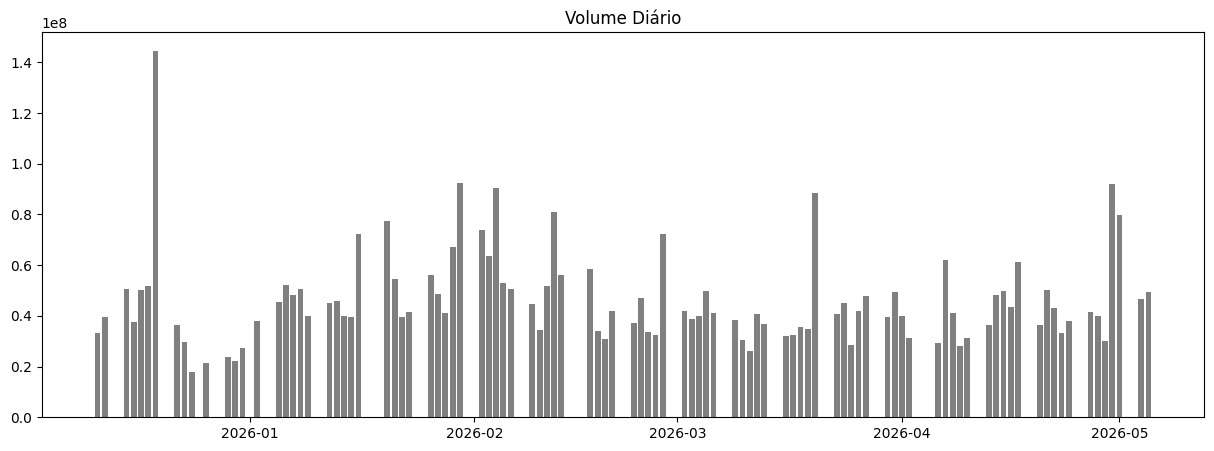

In [204]:
plt.figure(figsize = (15, 5))

plt.bar(df_clean.index, df_clean['volume'], color= 'gray')
plt.title('Volume Diário')

## DESAFIO: Histograma da Amplitude Normalizada

Text(0.5, 1.0, 'Histograma: Amplitude Normalizada')

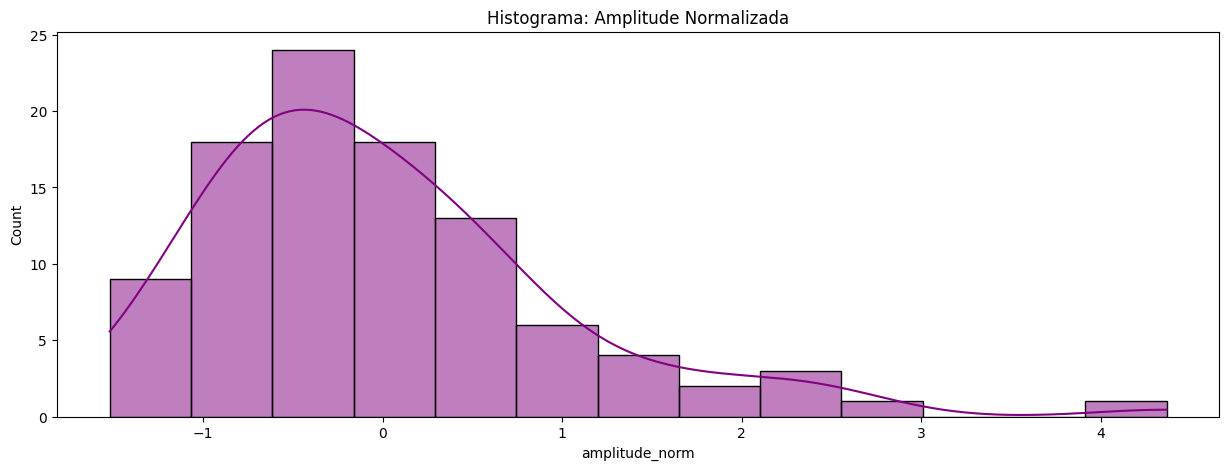

In [205]:
plt.figure(figsize = (15, 5))


sns.histplot(X['amplitude_norm'], kde = True, color = 'purple')
plt.title('Histograma: Amplitude Normalizada')

#4. Laborização (Feature Engineering)

## Média Móvel

In [192]:
df_clean['media_100'] = df_clean['amplitude_raw'].shift(1).rolling(window = 100, min_periods = 1).mean()

In [193]:
df_clean['Y'] = (df_clean['amplitude_raw'] > df_clean['media_100']).astype(int)

In [194]:
df_final = df_clean.dropna().copy()

In [195]:
print("Distribuição das classes (0: Baixa, 1: Alta):")
print(df_final['Y'].value_counts())

Distribuição das classes (0: Baixa, 1: Alta):
Y
0    52
1    46
Name: count, dtype: int64


#5. Ingestão Bayesiana

## Sincronizando os finais

In [196]:
y_final = df_final['Y']
X_final = X.loc[df_final.index]

## Divisão temporal

In [197]:
split_index = int(len(X_final) * 0.8)

X_train = X_final.iloc[:split_index]
X_test = X_final.iloc[split_index:]
y_train = y_final.iloc[:split_index]
y_test = y_final.iloc[split_index:]

## Treinamento do Modelo GaussianNB Naive Bayes

In [198]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

## Predição

In [199]:
y_pred = model.predict(X_test)

print(f"Acurácia Final: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação: \n", classification_report(y_test, y_pred))

Acurácia Final: 60.00%

Relatório de Classificação: 
               precision    recall  f1-score   support

           0       0.60      0.82      0.69        11
           1       0.60      0.33      0.43         9

    accuracy                           0.60        20
   macro avg       0.60      0.58      0.56        20
weighted avg       0.60      0.60      0.57        20

